In [1]:
!pip install kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"samihamuntahamahin","key":"3b6d29c9556db74812f31ee98a90662f"}'}

In [3]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p ./data1 --unzip

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:17<00:00, 18.0MB/s]



In [5]:
import os
import shutil
import random

# Paths
DATASET_PATH = "/content/data1/chest_xray/train"   # adjust if different
OUTPUT_PATH = "/content/data1/chest_xray/train/train2"

# Classes in dataset
classes = ["NORMAL","PNEUMONIA"]

# Make sure output train folder exists
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Process each class
for cls in classes:
    src_folder = os.path.join(DATASET_PATH, cls)
    dst_folder = os.path.join(OUTPUT_PATH, cls.replace(" ", "_"))  # replace spaces with underscore
    os.makedirs(dst_folder, exist_ok=True)

    # Get list of images
    images = [f for f in os.listdir(src_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # Shuffle to randomize
    random.shuffle(images)

    # Take images
    selected_images = images[:1300]

    # Copy to train folder
    for img in selected_images:
        shutil.copy(os.path.join(src_folder, img), os.path.join(dst_folder, img))

    print(f"{cls}: {len(selected_images)} images copied to {dst_folder}")

print(" Train dataset prepared successfully!")

NORMAL: 1300 images copied to /content/data1/chest_xray/train/train2/NORMAL
PNEUMONIA: 1300 images copied to /content/data1/chest_xray/train/train2/PNEUMONIA
 Train dataset prepared successfully!


In [6]:
train_dir = "/content/data1/chest_xray/train/train2"

# **Data Visualization**

Classes: ['PNEUMONIA', 'NORMAL']


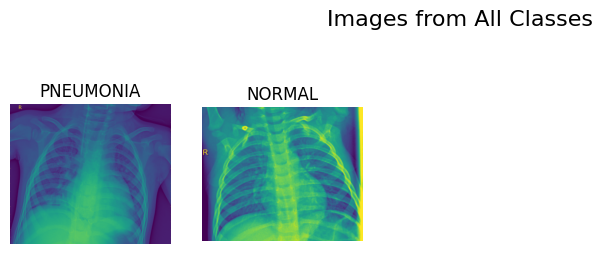

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random

classes = os.listdir(train_dir)
print("Classes:", classes)

# Show one random image from each class
plt.figure(figsize=(12, 6))
for i, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)

    # Pick a random image from that class
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    # Read image
    img = mpimg.imread(img_path)

    # Plot
    plt.subplot(2, 5, i+1)  # 2 rows, 5 columns
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.suptitle("Images from All Classes", fontsize=16)
plt.show()

/tmp/ipykernel_4205/2610198042.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="label", y="count", data=df, palette=he_colors)


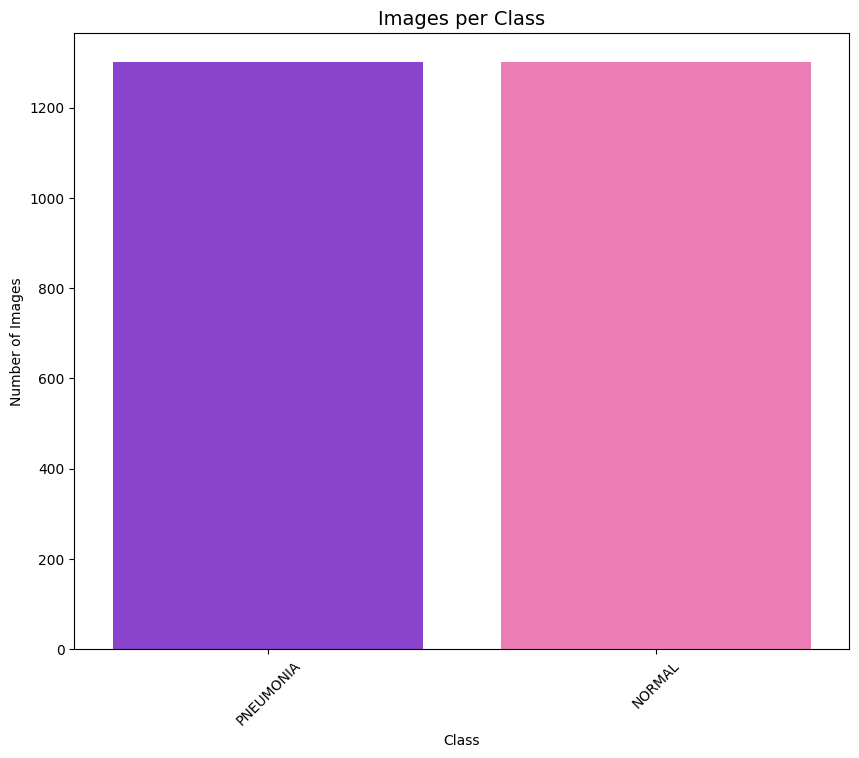

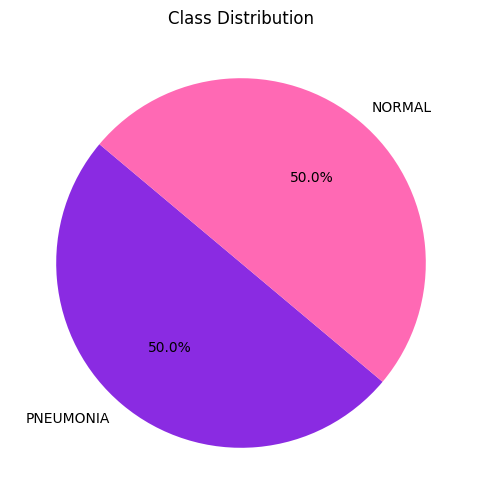

In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Count images per class
df = pd.DataFrame([(cls, len(os.listdir(os.path.join(train_dir, cls))))
                   for cls in os.listdir(train_dir)], columns=["label", "count"])

# H&E-inspired colors (purple/blue + pink)
he_colors = ["#8A2BE2", "#FF69B4"]

# Bar chart
plt.figure(figsize=(10, 8))
sns.barplot(x="label", y="count", data=df, palette=he_colors)
plt.xticks(rotation=45)
plt.title("Images per Class", fontsize=14)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

# Pie chart
df.set_index("label")["count"].plot(kind="pie", autopct="%1.1f%%",
                                    startangle=140, figsize=(6,6),
                                    colors=he_colors)
plt.title("Class Distribution")
plt.ylabel("")
plt.show()

# **Label Encoding**

In [9]:
from sklearn.preprocessing import LabelEncoder
import os
import pandas as pd

# Encoding the labels into numbers
encoder = LabelEncoder()
df["Label_num"] = encoder.fit_transform(df["label"])

# Create a list of image paths and their corresponding labels
image_paths = []
labels_num = []
for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)
    for img_name in os.listdir(cls_path):
        image_paths.append(os.path.join(cls_path, img_name))
        labels_num.append(encoder.transform([cls])[0])

# Create a DataFrame with image paths and numerical labels
df_balanced = pd.DataFrame({"image_path": image_paths, "label_num": labels_num})

print("\nClass counts:")
print(df_balanced["label_num"].value_counts())


Class counts:
label_num
1    1300
0    1300
Name: count, dtype: int64


# **Train-Test-Split**

In [10]:
from sklearn.model_selection import train_test_split

# Ensure label_num is integer type for sparse_categorical_crossentropy
df_balanced['label_num'] = df_balanced['label_num'].astype(str)

train_df, temp_df = train_test_split(df_balanced, train_size=0.8, shuffle=True,
                                     stratify=df_balanced['label_num'], random_state=42)

valid_df, test_df = train_test_split(temp_df, test_size=0.5, shuffle=True,
                                     stratify=temp_df['label_num'], random_state=42)

print("Train size:", train_df.shape)
print("Validation size:", valid_df.shape)
print("Test size:", test_df.shape)

Train size: (2080, 2)
Validation size: (260, 2)
Test size: (260, 2)


# **Data-Augmentation**

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input


batch_size = 32
img_size = (224, 224)

tr_gen = ImageDataGenerator(
   preprocessing_function=preprocess_input,
    rotation_range=15,           # small rotations only
    width_shift_range=0.05,      # slight horizontal shifts
    height_shift_range=0.05,     # slight vertical shifts
    zoom_range=0.1,              # mild zoom
    horizontal_flip=True,        # flipping is okay for US images
    vertical_flip=False,         # usually vertical flip is not applied in US images
    shear_range=0.05,            # small shear
    fill_mode='nearest'          # fill empty pixels
    )

ts_gen = ImageDataGenerator(preprocessing_function=preprocess_input)


train_gen = tr_gen.flow_from_dataframe(train_df, x_col='image_path', y_col='label_num',
                                       target_size=img_size, class_mode='sparse',
                                       color_mode='rgb', shuffle=True, batch_size=batch_size)

valid_gen = ts_gen.flow_from_dataframe(valid_df, x_col='image_path', y_col='label_num',
                                       target_size=img_size, class_mode='sparse',
                                       color_mode='rgb', shuffle=True, batch_size=batch_size)

test_gen = ts_gen.flow_from_dataframe(test_df, x_col='image_path', y_col='label_num',
                                      target_size=img_size, class_mode='sparse',
                                      color_mode='rgb', shuffle=False, batch_size=batch_size)

Found 2080 validated image filenames belonging to 2 classes.
Found 260 validated image filenames belonging to 2 classes.
Found 260 validated image filenames belonging to 2 classes.


# **MobileNetV3Small**

In [12]:
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecay

def create_efficientnet_simple(input_shape=(224,224,3), num_classes=2):
    inputs = Input(shape=input_shape)

    # Pretrained  without top layers
    base = MobileNetV3Small(weights='imagenet', include_top=False, input_tensor=inputs)

    # Freeze most layers except last 20 for fine-tuning
    for layer in base.layers[:-20]:
        layer.trainable = False

    # Base output
    x = base.output
    x = GlobalAveragePooling2D()(x)

    # Fully connected layers
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)

    # Output layer
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)


# Learning rate schedule (cosine decay)
lr_schedule = CosineDecay(
    initial_learning_rate=3e-4,  # starting LR
    decay_steps=1000,            # steps for one cycle
    alpha=1e-6                   # final LR fraction
)

# Create and compile model
model = create_efficientnet_simple(num_classes=2)
model.compile(
    optimizer=Adam(learning_rate=lr_schedule),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 113, 113,  │          0 │ activation[0][0]  │
│ (ZeroPadding2D)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │        144 │ expanded_conv_de… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 56, 56,    │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │          0 │ re_lu[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │        136 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │          0 │ expanded_conv_sq… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │        144 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 1, 16)  │          0 │ expanded_conv_sq… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 1, 1, 16)  │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1, 1, 16)  │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 56, 56,    │          0 │ re_lu[0][0],      │
│ (Multiply)          │ 16)               │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 56, 56,    │        256 │ expanded_conv_sq

 Total params: 1,368,434 (5.22 MB)

 Trainable params: 779,026 (2.97 MB)

 Non-trainable params: 589,408 (2.25 MB)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint("best_model.h5", monitor='val_accuracy', save_best_only=True, verbose=1)
]

history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=20,
    callbacks= callbacks,
    verbose=1
)

Epoch 1/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 690ms/step - accuracy: 0.7688 - loss: 0.6352
Epoch 1: val_accuracy improved from None to 0.65385, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
65/65 ━━━━━━━━━━━━━━━━━━━━ 83s 926ms/step - accuracy: 0.8558 - loss: 0.4124 - val_accuracy: 0.6538 - val_loss: 0.7189
Epoch 2/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 697ms/step - accuracy: 0.9341 - loss: 0.1850
Epoch 2: val_accuracy improved from 0.65385 to 0.83846, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
65/65 ━━━━━━━━━━━━━━━━━━━━ 49s 747ms/step - accuracy: 0.9385 - loss: 0.1769 - val_accuracy: 0.8385 - val_loss: 0.4149
Epoch 3/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 680ms/step - accuracy: 0.9414 - loss: 0.1604
Epoch 3: val_accuracy improved from 0.83846 to 0.88846, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
65/65 ━━━━━━━━━━━━━━━━━━━━ 50s 766ms/step - accuracy: 0.9418 - loss: 0.1705 - val_accuracy: 0.8885 - val_loss: 0.3127
Epoch 4/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 671ms/step - accuracy: 0.9615 - loss: 0.1120
Epoch 4: val_accuracy did not improve from 0.88846
65/65 ━━━━━━━━━━━━━━━━━━━━ 47s 730ms/step - accuracy: 0.9606 - loss: 0.1129 - val_accuracy: 0.8808 - val_loss: 0.3496
Epoch 5/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 667ms/step - accuracy: 0.9677 - loss: 0.1000
Epoch 5: val_accuracy improved from 0.88846 to 0.90385, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
65/65 ━━━━━━━━━━━━━━━━━━━━ 46s 715ms/step - accuracy: 0.9582 - loss: 0.1245 - val_accuracy: 0.9038 - val_loss: 0.3002
Epoch 6/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 680ms/step - accuracy: 0.9624 - loss: 0.1017
Epoch 6: val_accuracy improved from 0.90385 to 0.93077, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
65/65 ━━━━━━━━━━━━━━━━━━━━ 47s 728ms/step - accuracy: 0.9611 - loss: 0.1031 - val_accuracy: 0.9308 - val_loss: 0.1662
Epoch 7/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 684ms/step - accuracy: 0.9732 - loss: 0.0821
Epoch 7: val_accuracy improved from 0.93077 to 0.94615, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
65/65 ━━━━━━━━━━━━━━━━━━━━ 48s 732ms/step - accuracy: 0.9716 - loss: 0.0807 - val_accuracy: 0.9462 - val_loss: 0.1427
Epoch 8/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 668ms/step - accuracy: 0.9790 - loss: 0.0776
Epoch 8: val_accuracy did not improve from 0.94615
65/65 ━━━━━━━━━━━━━━━━━━━━ 49s 748ms/step - accuracy: 0.9769 - loss: 0.0755 - val_accuracy: 0.9462 - val_loss: 0.1443
Epoch 9/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 664ms/step - accuracy: 0.9644 - loss: 0.0946
Epoch 9: val_accuracy improved from 0.94615 to 0.95000, saving model to best_model.h5



Epoch 9: finished saving model to best_model.h5
65/65 ━━━━━━━━━━━━━━━━━━━━ 49s 750ms/step - accuracy: 0.9663 - loss: 0.0994 - val_accuracy: 0.9500 - val_loss: 0.1422
Epoch 10/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - accuracy: 0.9679 - loss: 0.0985
Epoch 10: val_accuracy did not improve from 0.95000
65/65 ━━━━━━━━━━━━━━━━━━━━ 46s 705ms/step - accuracy: 0.9716 - loss: 0.0778 - val_accuracy: 0.9500 - val_loss: 0.1367
Epoch 11/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 685ms/step - accuracy: 0.9768 - loss: 0.0653
Epoch 11: val_accuracy did not improve from 0.95000
65/65 ━━━━━━━━━━━━━━━━━━━━ 47s 727ms/step - accuracy: 0.9716 - loss: 0.0751 - val_accuracy: 0.9423 - val_loss: 0.1587
Epoch 12/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 689ms/step - accuracy: 0.9805 - loss: 0.0562
Epoch 12: val_accuracy did not improve from 0.95000
65/65 ━━━━━━━━━━━━━━━━━━━━ 48s 731ms/step - accuracy: 0.9755 - loss: 0.0704 - val_accuracy: 0.9423 - val_loss: 0.1532
Epoch 13/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 667ms/step - accurac

In [14]:
# Evaluate on the test generator
loss, accuracy = model.evaluate(test_gen, verbose=1)

print(f"Final Test Accuracy: {accuracy*100:.2f}%")
print(f"Final Test Loss: {loss:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 314ms/step - accuracy: 0.9692 - loss: 0.0766
Final Test Accuracy: 96.92%
Final Test Loss: 0.0766


In [15]:
from tensorflow.keras.models import load_model
model.load_weights('best_model.h5')
best_model = model

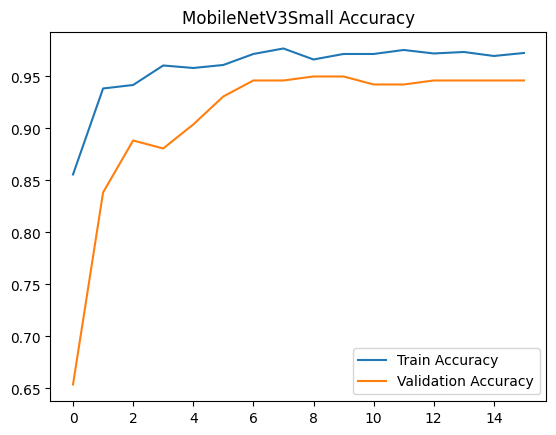

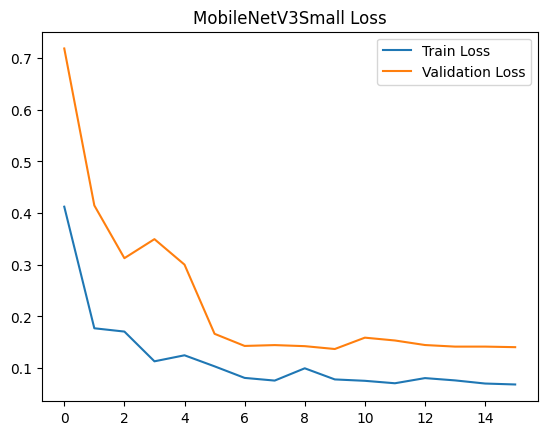

In [16]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("MobileNetV3Small Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("MobileNetV3Small Loss")
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 827ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       130
           1       0.99      0.95      0.97       130

    accuracy                           0.97       260
   macro avg       0.97      0.97      0.97       260
weighted avg       0.97      0.97      0.97       260



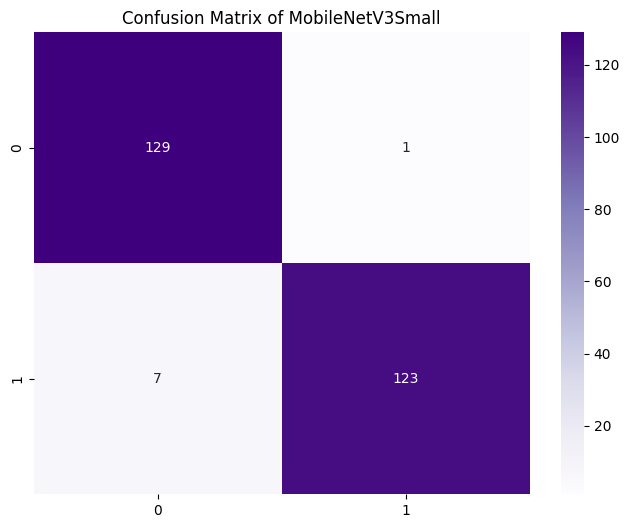

In [17]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# True labels from test generator
y_true = test_gen.classes

# Predictions
y_pred = np.argmax(model.predict(test_gen), axis=1) #argmax finds the index of the largest value in an array

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=list(test_gen.class_indices.keys())))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())
plt.title("Confusion Matrix of MobileNetV3Small")
plt.show()

# **Compute Flops,Measure Inference Time,Memory Consumption**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


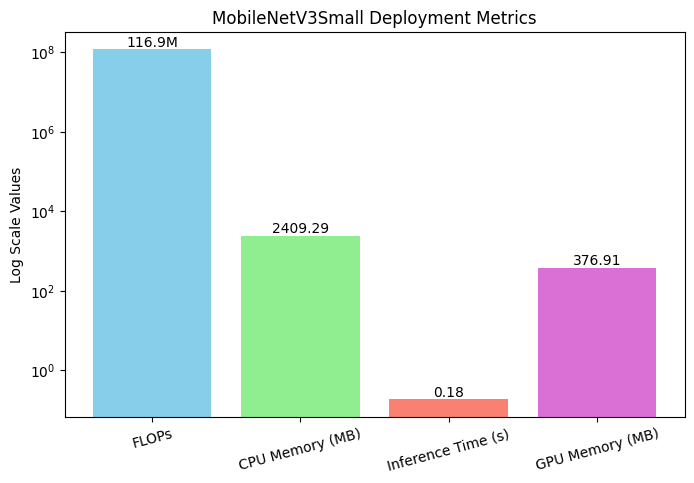

In [21]:
import tensorflow as tf
import time
import numpy as np
import psutil
import os
import matplotlib.pyplot as plt
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2

# -----------------------------
# 1. Compute FLOPs
# -----------------------------
def get_flops(model):
    input_shape = [1] + list(model.input_shape[1:])  # batch size 1
    concrete_func = tf.function(lambda x: model(x))
    concrete_func = concrete_func.get_concrete_function(
        tf.TensorSpec(input_shape, model.inputs[0].dtype)
    )
    frozen_func = convert_variables_to_constants_v2(concrete_func)
    graph_def = frozen_func.graph.as_graph_def()

    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(graph_def, name="")
        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
        flops = tf.compat.v1.profiler.profile(graph=graph, run_meta=run_meta, cmd='op', options=opts)
        return flops.total_float_ops

flops = get_flops(model)

# -----------------------------
# 2. Measure inference time
# -----------------------------
x_sample = np.random.rand(1, 224, 224, 3).astype(np.float32)
_ = model.predict(x_sample)  # warm-up

start_time = time.time()
_ = model.predict(x_sample)
inference_time = time.time() - start_time

# -----------------------------
# 3. Measure CPU and GPU memory
# -----------------------------
process = psutil.Process(os.getpid())
cpu_memory = process.memory_info().rss / (1024 ** 2)  # MB

gpu_memory = 0
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        # Construct the correct device string "GPU:X" from PhysicalDevice object
        # gpu.name is typically '/physical_device:GPU:0', we need 'GPU:0'
        gpu_device_string = f'{gpu.device_type}:{gpu.name.split(":")[-1]}'
        details = tf.config.experimental.get_memory_info(gpu_device_string)
        gpu_memory = details['peak'] / (1024 ** 2)  # MB

# -----------------------------
# 4. Prepare metrics for plotting
# -----------------------------
metrics = ['FLOPs', 'CPU Memory (MB)', 'Inference Time (s)']
values = [flops, cpu_memory, inference_time]

if gpu_memory > 0:
    metrics.append('GPU Memory (MB)')
    values.append(gpu_memory)

# Use log scale for better visualization
plt.figure(figsize=(8,5))
bars = plt.bar(metrics, values, color=['skyblue', 'lightgreen', 'salmon', 'orchid'])
plt.yscale('log')
plt.title("MobileNetV3Small Deployment Metrics")
plt.ylabel("Log Scale Values")
plt.xticks(rotation=15)

# Annotate bars with readable values
for i, bar in enumerate(bars):
    height = bar.get_height()
    if metrics[i] == 'FLOPs':
        plt.text(bar.get_x() + bar.get_width()/2, height, f'{height/1e6:.1f}M', ha='center', va='bottom')
    else:
        plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}', ha='center', va='bottom')

plt.show()

# **AUC-ROC**

In [22]:
y_prob = model.predict(test_gen)

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 316ms/step


9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 313ms/step


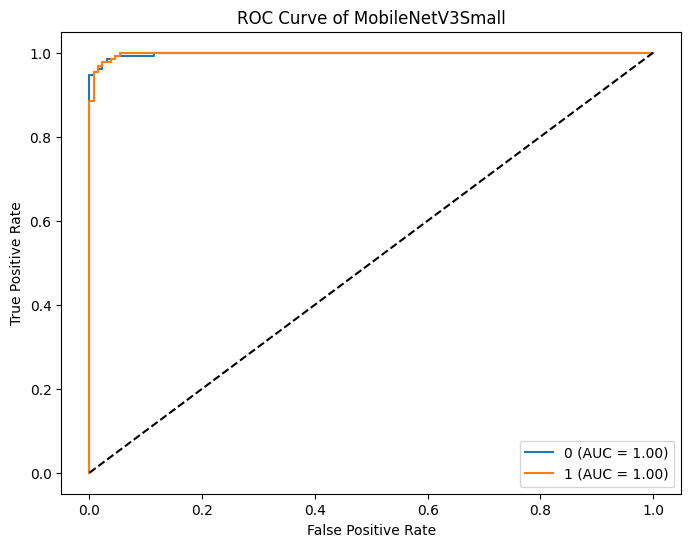

In [23]:
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Number of classes
class_names = list(test_gen.class_indices.keys())
n_classes = len(class_names)

# True labels
y_true = np.array(test_gen.classes) # Converted to NumPy array here

# Predicted probabilities (softmax outputs)
y_prob = model.predict(test_gen)

# Plot ROC curves
plt.figure(figsize=(8, 6))

for i in range(n_classes):
    # For each class, treat it as the positive class
    # Convert y_true to binary labels (1 if it's class i, 0 otherwise)
    y_true_for_class_i = (y_true == i).astype(int)

    # Use the probabilities for class i
    y_score_for_class_i = y_prob[:, i]

    fpr, tpr, _ = roc_curve(y_true_for_class_i, y_score_for_class_i)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

# Random chance line
plt.plot([0, 1], [0, 1], 'k--')

plt.title("ROC Curve of MobileNetV3Small")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

# **Grad-Cam Visualization**


Grad-CAM for class 1: /content/data1/chest_xray/train/train2/PNEUMONIA/person388_virus_777.jpeg


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


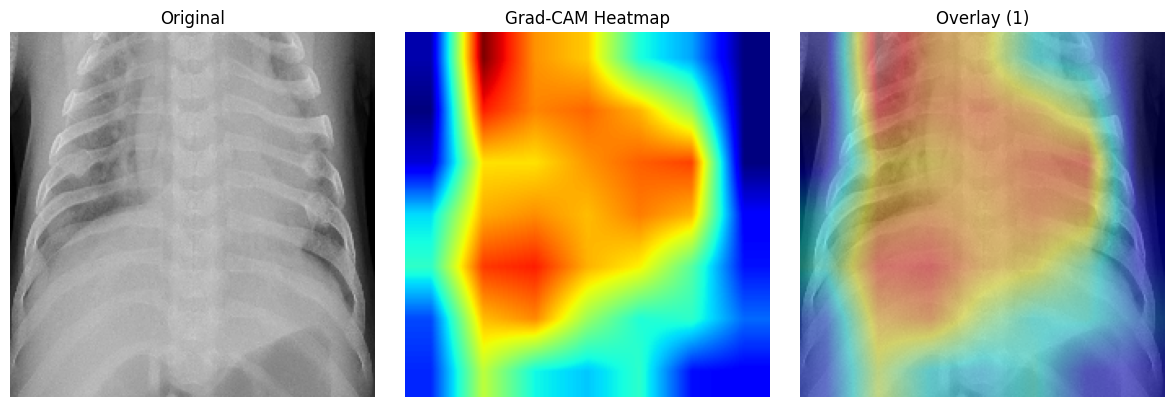

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Predicted class id: 1 | Probability: 1.000
True class: 1

Grad-CAM for class 0: /content/data1/chest_xray/train/train2/NORMAL/IM-0635-0001.jpeg


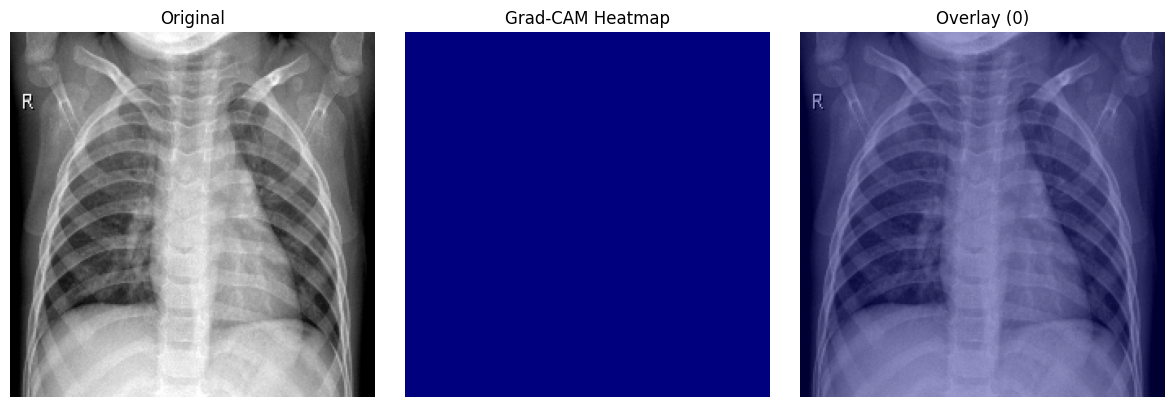

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted class id: 0 | Probability: 1.000
True class: 0


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
import cv2

# Import MobileNet's preprocess_input
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_preprocess_input

# ---------- Grad-CAM function ----------
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="activation_17", pred_index=None):
    """
    Generates Grad-CAM heatmap for a single image.
    """
    # Model: input -> last conv layer + output
    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# ---------- Display function ----------
def display_gradcam(img_path, model, class_name=None, last_conv_layer_name="activation_13", alpha=0.4):
    """
    Load image, generate Grad-CAM, display original, heatmap, and overlay.
    """
    img_size = (224,224)
    # Load & preprocess
    img = tf.keras.utils.load_img(img_path, target_size=img_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array_exp = np.expand_dims(img_array, axis=0)
    # Use MobileNet's preprocess_input
    img_array_exp = mobilenet_preprocess_input(img_array_exp)

    # Grad-CAM
    heatmap = make_gradcam_heatmap(img_array_exp, model, last_conv_layer_name)

    # Resize and overlay
    heatmap_resized = cv2.resize(heatmap, img_size)
    heatmap_uint8 = np.uint8(255*heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

    original_img = cv2.imread(img_path)
    original_img = cv2.resize(original_img, img_size)

    overlay_img = cv2.addWeighted(original_img, 1-alpha, heatmap_color, alpha, 0)

    # Plot
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(heatmap_resized, cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB))
    title_str = "Overlay"
    if class_name:
        title_str += f" ({class_name})"
    plt.title(title_str)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # Prediction info
    preds = model.predict(img_array_exp)
    pred_idx = np.argmax(preds)
    pred_prob = preds[0][pred_idx]
    print(f"Predicted class id: {pred_idx} | Probability: {pred_prob:.3f}")
    if class_name:
        print(f"True class: {class_name}")

# ---------- Pick one sample image per class ----------
class_ids = test_df['label_num'].unique()
sample_imgs = []
for cls in class_ids:
    img_path = test_df[test_df['label_num']==cls]['image_path'].iloc[0]
    sample_imgs.append((img_path, cls))

# ---------- Display Grad-CAM for each class ----------
for img_path, cls in sample_imgs:
    class_name = str(cls)  # optionally map to actual class names
    print(f"\nGrad-CAM for class {cls}: {img_path}")
    display_gradcam(img_path, best_model, class_name=class_name, last_conv_layer_name="activation_13")


Grad-CAM for class 1: /content/data1/chest_xray/train/train2/PNEUMONIA/person1264_bacteria_3222.jpeg


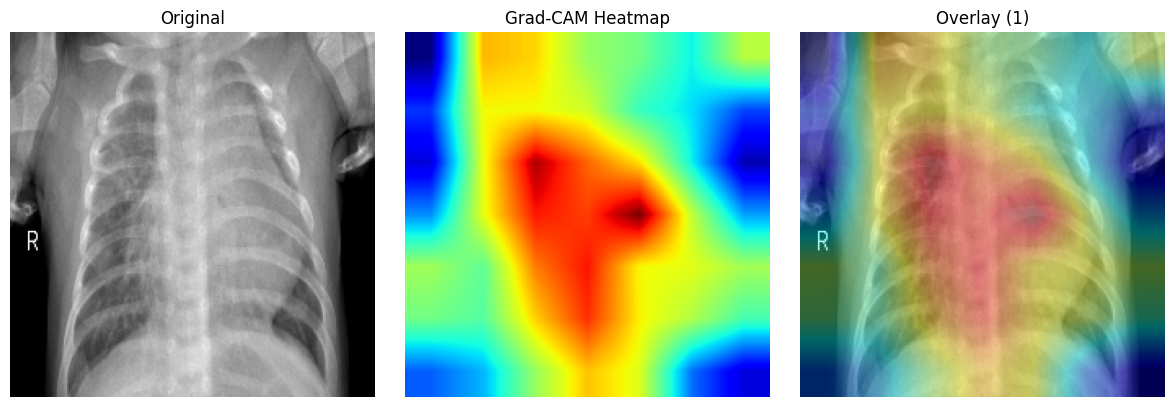

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Predicted class id: 1 | Probability: 0.958
True class: 1

Grad-CAM for class 0: /content/data1/chest_xray/train/train2/NORMAL/NORMAL2-IM-0522-0001.jpeg


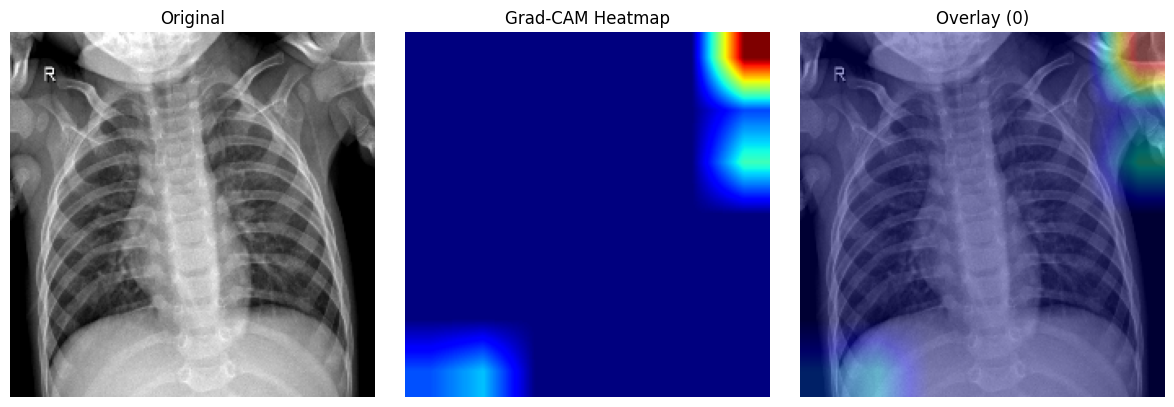

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Predicted class id: 0 | Probability: 0.925
True class: 0


In [25]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
import cv2

# Import MobileNet's preprocess_input
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_preprocess_input

# ---------- Grad-CAM function ----------
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="activation_17", pred_index=None):
    """
    Generates Grad-CAM heatmap for a single image.
    """
    # Model: input -> last conv layer + output
    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# ---------- Display function ----------
def display_gradcam(img_path, model, class_name=None, last_conv_layer_name="activation_13", alpha=0.4):
    """
    Load image, generate Grad-CAM, display original, heatmap, and overlay.
    """
    img_size = (224,224)
    # Load & preprocess
    img = tf.keras.utils.load_img(img_path, target_size=img_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array_exp = np.expand_dims(img_array, axis=0)
    # Use MobileNet's preprocess_input
    img_array_exp = mobilenet_preprocess_input(img_array_exp)

    # Grad-CAM
    heatmap = make_gradcam_heatmap(img_array_exp, model, last_conv_layer_name)

    # Resize and overlay
    heatmap_resized = cv2.resize(heatmap, img_size)
    heatmap_uint8 = np.uint8(255*heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

    original_img = cv2.imread(img_path)
    original_img = cv2.resize(original_img, img_size)

    overlay_img = cv2.addWeighted(original_img, 1-alpha, heatmap_color, alpha, 0)

    # Plot
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(heatmap_resized, cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB))
    title_str = "Overlay"
    if class_name:
        title_str += f" ({class_name})"
    plt.title(title_str)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # Prediction info
    preds = model.predict(img_array_exp)
    pred_idx = np.argmax(preds)
    pred_prob = preds[0][pred_idx]
    print(f"Predicted class id: {pred_idx} | Probability: {pred_prob:.3f}")
    if class_name:
        print(f"True class: {class_name}")

# ---------- Pick one sample image per class ----------
class_ids = test_df['label_num'].unique()
sample_imgs = []
for cls in class_ids:
    img_path = test_df[test_df['label_num']==cls]['image_path'].iloc[1]
    sample_imgs.append((img_path, cls))

# ---------- Display Grad-CAM for each class ----------
for img_path, cls in sample_imgs:
    class_name = str(cls)  # optionally map to actual class names
    print(f"\nGrad-CAM for class {cls}: {img_path}")
    display_gradcam(img_path, best_model, class_name=class_name, last_conv_layer_name="activation_13")


Grad-CAM for class 1: /content/data1/chest_xray/train/train2/PNEUMONIA/person1355_virus_2336.jpeg


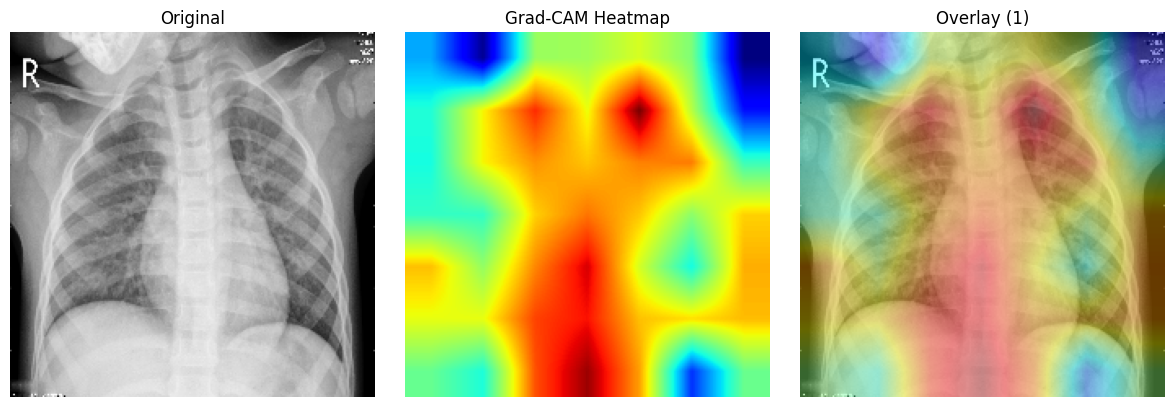

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Predicted class id: 1 | Probability: 0.924
True class: 1

Grad-CAM for class 0: /content/data1/chest_xray/train/train2/NORMAL/IM-0456-0001.jpeg


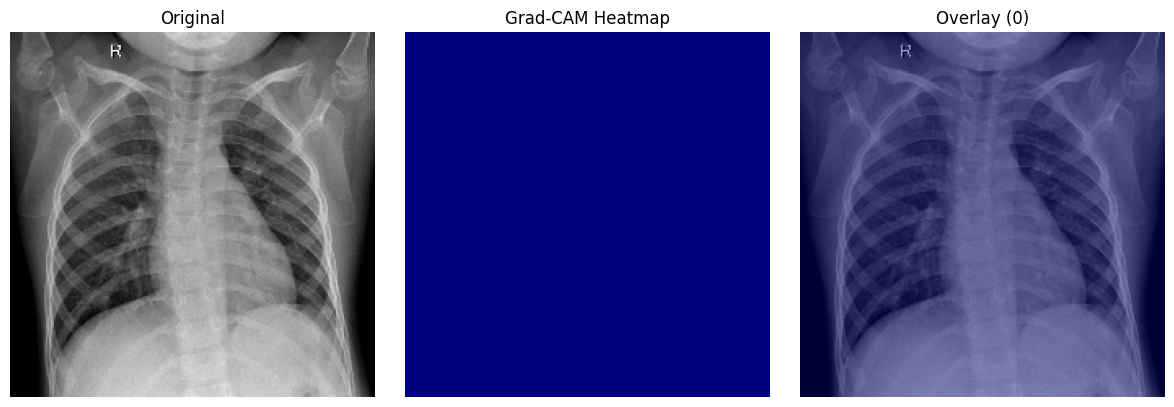

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted class id: 0 | Probability: 0.998
True class: 0


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
import cv2

# Import MobileNet's preprocess_input
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_preprocess_input

# ---------- Grad-CAM function ----------
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="activation_17", pred_index=None):
    """
    Generates Grad-CAM heatmap for a single image.
    """
    # Model: input -> last conv layer + output
    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# ---------- Display function ----------
def display_gradcam(img_path, model, class_name=None, last_conv_layer_name="activation_13", alpha=0.4):
    """
    Load image, generate Grad-CAM, display original, heatmap, and overlay.
    """
    img_size = (224,224)
    # Load & preprocess
    img = tf.keras.utils.load_img(img_path, target_size=img_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array_exp = np.expand_dims(img_array, axis=0)
    # Use MobileNet's preprocess_input
    img_array_exp = mobilenet_preprocess_input(img_array_exp)

    # Grad-CAM
    heatmap = make_gradcam_heatmap(img_array_exp, model, last_conv_layer_name)

    # Resize and overlay
    heatmap_resized = cv2.resize(heatmap, img_size)
    heatmap_uint8 = np.uint8(255*heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

    original_img = cv2.imread(img_path)
    original_img = cv2.resize(original_img, img_size)

    overlay_img = cv2.addWeighted(original_img, 1-alpha, heatmap_color, alpha, 0)

    # Plot
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(heatmap_resized, cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB))
    title_str = "Overlay"
    if class_name:
        title_str += f" ({class_name})"
    plt.title(title_str)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # Prediction info
    preds = model.predict(img_array_exp)
    pred_idx = np.argmax(preds)
    pred_prob = preds[0][pred_idx]
    print(f"Predicted class id: {pred_idx} | Probability: {pred_prob:.3f}")
    if class_name:
        print(f"True class: {class_name}")

# ---------- Pick one sample image per class ----------
class_ids = test_df['label_num'].unique()
sample_imgs = []
for cls in class_ids:
    img_path = test_df[test_df['label_num']==cls]['image_path'].iloc[6]
    sample_imgs.append((img_path, cls))

# ---------- Display Grad-CAM for each class ----------
for img_path, cls in sample_imgs:
    class_name = str(cls)  # optionally map to actual class names
    print(f"\nGrad-CAM for class {cls}: {img_path}")
    display_gradcam(img_path, best_model, class_name=class_name, last_conv_layer_name="activation_13")


Grad-CAM for class 1: /content/data1/chest_xray/train/train2/PNEUMONIA/person979_virus_1654.jpeg


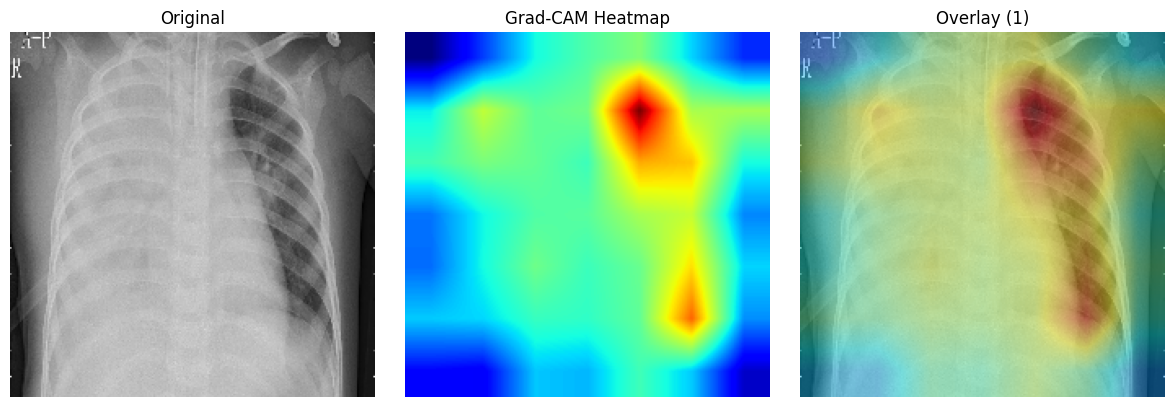

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Predicted class id: 1 | Probability: 1.000
True class: 1

Grad-CAM for class 0: /content/data1/chest_xray/train/train2/NORMAL/IM-0304-0001.jpeg


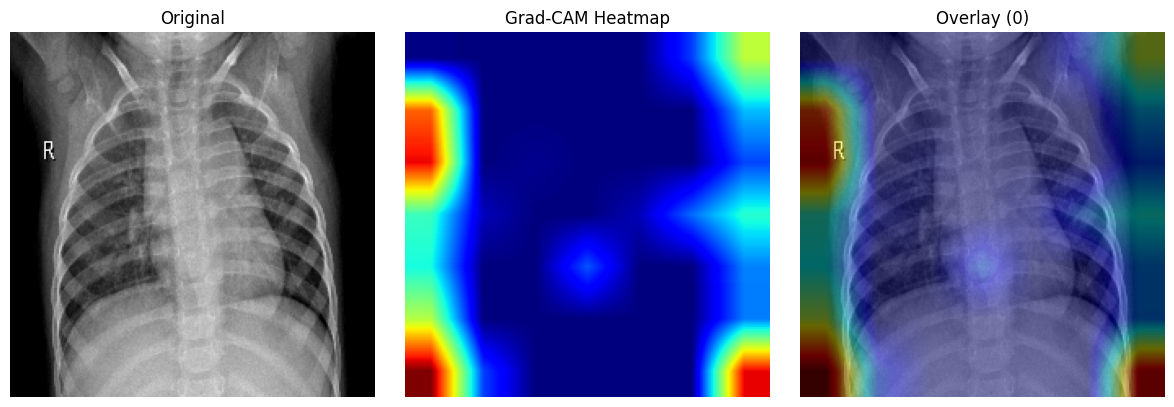

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Predicted class id: 0 | Probability: 0.992
True class: 0


In [59]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
import cv2

# Import MobileNet's preprocess_input
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_preprocess_input

# ---------- Grad-CAM function ----------
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="activation_17", pred_index=None):
    """
    Generates Grad-CAM heatmap for a single image.
    """
    # Model: input -> last conv layer + output
    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# ---------- Display function ----------
def display_gradcam(img_path, model, class_name=None, last_conv_layer_name="activation_17", alpha=0.4):
    """
    Load image, generate Grad-CAM, display original, heatmap, and overlay.
    """
    img_size = (224,224)
    # Load & preprocess
    img = tf.keras.utils.load_img(img_path, target_size=img_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array_exp = np.expand_dims(img_array, axis=0)
    # Use MobileNet's preprocess_input
    img_array_exp = mobilenet_preprocess_input(img_array_exp)

    # Grad-CAM
    heatmap = make_gradcam_heatmap(img_array_exp, model, last_conv_layer_name)

    # Resize and overlay
    heatmap_resized = cv2.resize(heatmap, img_size)
    heatmap_uint8 = np.uint8(255*heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

    original_img = cv2.imread(img_path)
    original_img = cv2.resize(original_img, img_size)

    overlay_img = cv2.addWeighted(original_img, 1-alpha, heatmap_color, alpha, 0)

    # Plot
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(heatmap_resized, cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB))
    title_str = "Overlay"
    if class_name:
        title_str += f" ({class_name})"
    plt.title(title_str)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # Prediction info
    preds = model.predict(img_array_exp)
    pred_idx = np.argmax(preds)
    pred_prob = preds[0][pred_idx]
    print(f"Predicted class id: {pred_idx} | Probability: {pred_prob:.3f}")
    if class_name:
        print(f"True class: {class_name}")

# ---------- Pick one sample image per class ----------
class_ids = test_df['label_num'].unique()
sample_imgs = []
for cls in class_ids:
    img_path = test_df[test_df['label_num']==cls]['image_path'].iloc[2]
    sample_imgs.append((img_path, cls))

# ---------- Display Grad-CAM for each class ----------
for img_path, cls in sample_imgs:
    class_name = str(cls)  # optionally map to actual class names
    print(f"\nGrad-CAM for class {cls}: {img_path}")
    display_gradcam(img_path, best_model, class_name=class_name, last_conv_layer_name="activation_13")

# **Monte Carlo Dropout (MC Dropout)**

Data Source: Instead of loading one image manually (which might have different preprocessing), we grab a batch directly from test_gen.

Batch Norm Stability: By passing 32 images at once (from next(iter(test_gen))), the BatchNormalization layers can calculate a valid mean and variance.

Running MC Dropout on 5 batches (Batch Size: 32)...

Average Uncertainty: 0.0771
Min Uncertainty: 0.0000
Max Uncertainty: 0.6910


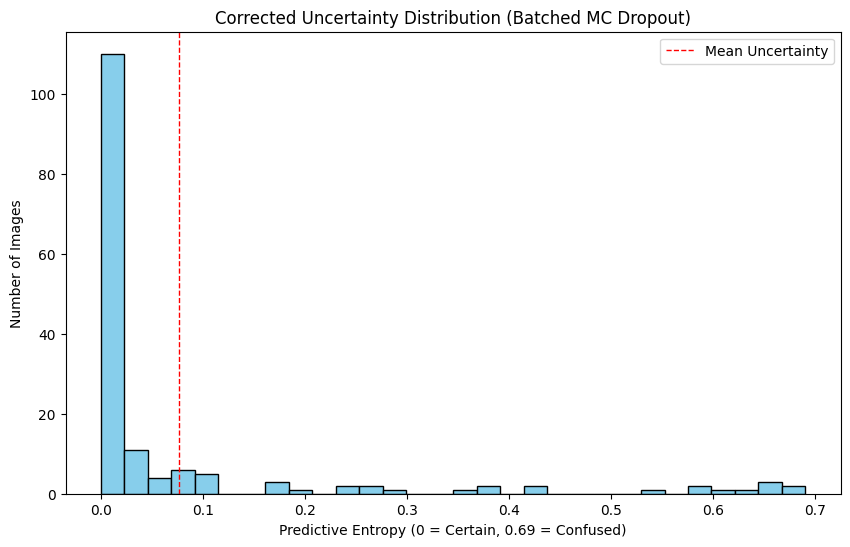

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def mc_dropout_predict_batch(model, generator, T=50, num_batches=1):
    """
    Runs MC Dropout on batches from a generator to ensure BatchNorm works correctly.
    """
    all_uncertainties = []

    # Get iterator from generator
    data_iter = iter(generator)

    print(f"Running MC Dropout on {num_batches} batches (Batch Size: {generator.batch_size})...")

    for _ in range(num_batches):
        # Get one batch of images and labels
        imgs, labels = next(data_iter)

        # Store predictions for this batch across T iterations
        # Shape: (T, Batch_Size, Num_Classes)
        batch_preds = []

        for _ in range(T):
            # training=True ensures Dropout is ACTIVE
            # Since we pass a batch (size 32), BatchNorm works correctly now
            pred = model(imgs, training=True)
            batch_preds.append(pred.numpy())

        batch_preds = np.array(batch_preds)

        # Calculate Mean Prediction (Average probability)
        mean_preds = batch_preds.mean(axis=0)

        # Calculate Predictive Entropy (Uncertainty)
        epsilon = 1e-8
        entropy = -np.sum(mean_preds * np.log(mean_preds + epsilon), axis=1)

        all_uncertainties.extend(entropy)

    return np.array(all_uncertainties)

# ---------------------------------------------------------
# EXECUTE THE FIX
# ---------------------------------------------------------

# 1. Run on a few batches (e.g., 5 batches = 160 images if batch_size=32)
# We use the generator directly to ensure preprocessing matches exactly
uncertainties = mc_dropout_predict_batch(model, test_gen, T=50, num_batches=5)

# 2. Check the statistics now
print(f"\nAverage Uncertainty: {np.mean(uncertainties):.4f}")
print(f"Min Uncertainty: {np.min(uncertainties):.4f}")
print(f"Max Uncertainty: {np.max(uncertainties):.4f}")

# 3. Plot the Corrected Histogram
plt.figure(figsize=(10, 6))
plt.hist(uncertainties, bins=30, color='skyblue', edgecolor='black')
plt.axvline(np.mean(uncertainties), color='red', linestyle='dashed', linewidth=1, label='Mean Uncertainty')
plt.xlabel("Predictive Entropy (0 = Certain, 0.69 = Confused)")
plt.ylabel("Number of Images")
plt.title(f"Corrected Uncertainty Distribution (Batched MC Dropout)")
plt.legend()
plt.show()